In [1]:
import os
import re
import json
from tqdm import tqdm
import gc

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from Bio.PDB import PDBParser, PPBuilder
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors

from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint, loguniform
from sklearn.metrics import mean_squared_error, r2_score

gc.collect()

0

### Functions

In [2]:
def evaluate_model(model, train_data, test_datasets, title, fit=True, figsize=(10, 10)):
    """
    Train and evaluate a regression model on multiple test datasets with scatter plots.
    
    Parameters
    ----------
    model : sklearn-like regressor
        The model to train and evaluate.
    train_data : tuple
        (X_train, y_train) data for fitting if fit=True.
    test_datasets : dict
        Dictionary of test datasets: {"name": (X_test, y_test), ...}.
    title : str
        Title for the entire figure.
    fit : bool, optional
        Whether to fit the model before evaluating (default: True).
    figsize : tuple, optional
        Figure size.
    """

    X_train, y_train = train_data
    if fit:
        model.fit(X_train, y_train)

    fig, axes = plt.subplots(2, 2, figsize=figsize, constrained_layout=True)
    axes = axes.flatten()

    for ax, (name, (X_test, y_test)) in zip(axes, test_datasets.items()):
        y_pred = model.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        pearson_corr = np.corrcoef(y_test, y_pred)[0, 1]

        ax.scatter(y_test, y_pred, alpha=0.6)
        ax.plot(y_test, y_test, color='red', linestyle='--')
        ax.set_title(f"{name.upper()}\nR²={r2:.3f}, RMSE={rmse:.3f}, PCC={pearson_corr:.3f}")
        ax.set_xlabel("True pK")
        ax.set_ylabel("Predicted pK")
        ax.grid(True, linestyle='--', alpha=0.5)

    fig.suptitle(title, fontsize=14, y=1.02)
    plt.show()

---


In [ ]:
# Data path
DATA_PATH = r"C:\ZHAW\PA2\data\PDBbind_v2021_by_2020"

# List all files and directories
for dirpath, dirnames, filenames in os.walk(DATA_PATH):
    print(f"Current folder: {dirpath}")
    print("Subfolders:", dirnames)
    print("Files:", filenames)

# ---------- Helper Functions ----------
def pdb_to_sequence(pdb_file):
    """Convert a PDB file to amino acid sequence(s)"""
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("protein", pdb_file)
    ppb = PPBuilder()
    seqs = [str(pp.get_sequence()) for pp in ppb.build_peptides(structure)]
    return seqs

def mol2_to_smiles(mol2_file):
    """Convert MOL2 to a SMILES string"""
    try:
        mol = Chem.MolFromMol2File(mol2_file, sanitize=True)
        if mol:
            return Chem.MolToSmiles(mol)
    except Exception:
        pass
    return None

def process_complex(complex_folder):
    """Process one PDBbind subfolder: extract protein + pocket sequences + ligand SMILES"""
    pdb_id = os.path.basename(complex_folder)

    # protein sequence
    protein_file = next((f for f in os.listdir(complex_folder) if f.endswith("_protein.pdb")), None)
    sequences = pdb_to_sequence(os.path.join(complex_folder, protein_file)) if protein_file else []

    # Pocket sequence
    pocket_file = next((f for f in os.listdir(complex_folder) if f.endswith("_pocket.pdb")), None)
    pocket_sequences = pdb_to_sequence(os.path.join(complex_folder, pocket_file)) if pocket_file else []

    # Ligand SMILES (MOL2 file)
    mol2_file = next((f for f in os.listdir(complex_folder) if f.endswith(".mol2")), None)
    smiles_list = []
    if mol2_file:
        smi = mol2_to_smiles(os.path.join(complex_folder, mol2_file))
        if smi:
            smiles_list.append(smi)

    return {
        "pdb_id": pdb_id,
        "protein_sequences": sequences,
        "pocket_sequences": pocket_sequences,
        "ligand_smiles": smiles_list
    }

# data 
root = DATA_PATH
subfolders = [os.path.join(root, d) for d in os.listdir(root)
              if os.path.isdir(os.path.join(root, d))]

# Process all complexes
results = []
for folder in tqdm(subfolders, desc="Processing complexes"):
    results.append(process_complex(folder))

# Save CSV 
rows = []
for entry in results:
    pdb_id = entry["pdb_id"]
    protein_sequences = entry["protein_sequences"]
    pocket_sequences = entry["pocket_sequences"]
    smiles_list = entry["ligand_smiles"]

    smi = smiles_list[0] if smiles_list else None
    rows.append({
        "pdb_id": pdb_id,
        "protein_sequences": protein_sequences,
        "pocket_sequences": pocket_sequences,
        "ligand_smiles": smi
    })

df = pd.DataFrame(rows)
df.to_csv("PDBbind_protein_pocket_ligands.csv", index=False)
print("CSV file saved.")

## **Data Preprocessing**

In [9]:
# Load and clean PDBbind_protein_pocket_ligands.csv
df = pd.read_csv("PDBbind_protein_pocket_ligands.csv")
df = df.dropna() # Delete rows with NA
df

,pdb_id,protein_sequences,pocket_sequences,ligand_smiles
0,10gs,['PYTVVYFPVRGRCAALRMLLADQGQSWKEEVVTVETWQEGSLKA...,"['VYFPVRGRCAALR', 'VVTVETWQEG', 'LKA', 'CLYGQL...",[NH3+][C@@H](CCC(=O)N[C@@H](CSCc1ccccc1)C(=O)N...
1,11gs,['PYTVVYFPVRGRCAALRMLLADQGQSWKEEVVTVETWQEGSLKA...,"['VYFPVRGRCAALR', 'VVTVETWQEG', 'LKA', 'CLYGQL...",CC[C@@H](CSC[C@H](NC(=O)CC[C@H]([NH3+])C(=O)[O...
2,13gs,['MPPYTVVYFPVRGRCAALRMLLADQGQSWKEEVVTVETWQEGSL...,"['YFPVRGRCAA', 'VVTVETWQE', 'LK', 'QLP', 'QSN'...",O=C([O-])C1=C/C(=N\Nc2ccc(S(=O)(=O)Nc3ccccn3)c...
3,16pk,['EKKSINECDLKGKKVLIRVDFNVPVKNGKITNDYRIRSALPTLK...,"['GR', 'AFGTAHR', 'IVGGAKVSDKI', 'IGGAMAYT', '...",Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO[P@](=O)([O-])O[...
4,184l,['MNIFEMLRIDEGLRLKIYKDTEGYYTIGIGHLLTKSPSLNAAKS...,"['AV', 'GILRNAKLKPVYDSLD', 'RRAAAINMVFQMGETGVA...",CC(C)Cc1ccccc1
...,...,...,...,...
19055,966c,['RWEQTHLTYRIENYTPDLPRADVDHAIEKAFQLWSNVTPLTFTK...,"['LW', 'SPFDGPGGNLAHAFQ', 'DAHFD', 'EYNLHRVAAH...",O=C(CC1(S(=O)(=O)c2ccc(Oc3ccccc3)cc2)CCOCC1)NO
19056,9abp,['NLKLGFLVKQPEEPWFQTEWKFADKAGKDLGFEVIKIAVPDGEK...,"['FLVKQPEEPWFQTE', 'ICTPDP', 'AVDDQ', 'LVMMAA'...",OC[C@H]1O[C@H](O)[C@H](O)[C@@H](O)[C@H]1O
19057,9hvp,['PQITLWQRPLVTIKIGGQLKEALLDTGADDTVLEEMNLPGRWKP...,"['RPL', 'ALLDTGADDTVLE', 'KMIGGIGGFIKV', 'VL',...",CC(C)[C@H](N[C]([O-])OCc1ccccc1)C(=O)N[C@@H](C...
19058,9icd,['SKVVVPAQGKKITLQNGKLNVPENPIIPYIEGDGIGVDVTPAML...,"['DGIGVDVT', 'AM', 'GPLTT', 'GGIGIAP', 'EATHGT...",Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)([O-])[O-])...


#### Amino acid - Codes

| 1-Letter | 3-Letter | Name            |
|----------|----------|-----------------|
| A        | Ala      | Alanin          |
| C        | Cys      | Cystein         |
| D        | Asp      | Asparaginsäure  |
| E        | Glu      | Glutaminsäure   |
| F        | Phe      | Phenylalanin    |
| G        | Gly      | Glycin          |
| H        | His      | Histidin        |
| I        | Ile      | Isoleucin       |
| K        | Lys      | Lysin           |
| L        | Leu      | Leucin          |
| M        | Met      | Methionin       |
| N        | Asn      | Asparagin       |
| P        | Pro      | Prolin          |
| Q        | Gln      | Glutamin        |
| R        | Arg      | Arginin         |
| S        | Ser      | Serin           |
| T        | Thr      | Threonin        |
| V        | Val      | Valin           |
| W        | Trp      | Tryptophan      |
| Y        | Tyr      | Tyrosin         |


#### **Load Index and calculate pk - values**

In [11]:
# ---------- Helper Function ----------
def parse_binding(binding_str):
    """
    Parse binding data like 'Ki=540nM', 'Kd=0.010uM', 'Ki<=17nM', 'Ki=3pM'
    and return pK value (float). Returns np.nan if parsing fails.
    """
    if pd.isna(binding_str):
        return np.nan
    
    # Regex to extract sign, value, and unit
    match = re.search(r'([<>]?=?)[\s]*([\d\.]+)[\s]*([munpμ]?M)', binding_str)
    if not match:
        return np.nan
    
    sign, value, unit = match.groups()
    value = float(value)
    
    # Calculate molar concentration
    unit = unit.lower()
    if unit == "mm":  # Millimolar
        molar = value * 1e-3
    elif unit == "um":  # Micromolar
        molar = value * 1e-6
    elif unit == "nm":  # Nanomolar
        molar = value * 1e-9
    elif unit == "pm":  # Picomolar
        molar = value * 1e-12
    else:
        return np.nan
    
    # Calculate pK
    pK = -np.log10(molar)
    
    # If it's a limit (e.g., < or <=), return NaN or handle as needed
    if sign in ["<", "<="]:
        return np.nan  
    
    return pK

# Load and parse INDEX_general_PL.2021_filtered_by_2020 (from uM to pk)
with open("INDEX_general_PL.2021_filtered_by_2020", "r") as f:
    lines = [line.strip() for line in f if not line.startswith("#") and line.strip()]

# Split lines into columns
data = []
for line in lines:
    parts = line.split("//")  # split at //
    main = parts[0].split()   # split main part by whitespace
    
    pdb_id = main[0]
    resolution = main[1]
    year = main[2]
    binding_data = main[3]
    comment = parts[1].strip() if len(parts) > 1 else ""
    
    data.append([pdb_id, resolution, year, binding_data, comment])

# Create DataFrame
df_index = pd.DataFrame(data, columns=["pdb_id", "resolution", "year", "binding_data", "comment"])

# Calculate pK values
df_index["pK"] = df_index["binding_data"].apply(parse_binding)

# Drop rows with NaN pK values
df_index = df_index.dropna(subset=["pK"]).reset_index(drop=True)
df_index

,pdb_id,resolution,year,binding_data,comment,pK
0,2tpi,2.10,1982,Kd=49uM,2tpi.pdf (2-mer),4.309804
1,5tln,2.30,1982,Ki=0.43uM,5tln.pdf (BAN) incomplete ligand structure,6.366532
2,4tln,2.30,1982,Ki=190uM,4tln.pdf (LNO),3.721246
3,6rsa,NMR,1986,Ki=40uM,6rsa.pdf (UVC),4.397940
4,1rnt,1.90,1987,Kd=6.5uM,1rnt.pdf (2GP),5.187087
...,...,...,...,...,...,...
18888,6k04,1.25,2019,Ki=9.1nM,6k04.pdf (CQF) ligand is 40,8.040959
18889,6q8a,2.11,2019,Ki=9.8nM,6hb5.pdf (HQ5) [Incomplete ligand],8.008774
18890,6ic2,1.15,2019,Ki=917.4nM,6ic2.pdf (BBJ) ligand is EPA,6.037441
18891,6gvh,2.74,2019,Ki=920nM,6gvf.pdf (FDH) ligand is 3e,6.036212


### **Options to encode Protein Sequences**

| Method                                          | Description                                                                      | Advantage                                          | Disadvantage                                               |
| ----------------------------------------------- | -------------------------------------------------------------------------------- | -------------------------------------------------- | ---------------------------------------------------------- |
| **One-Hot Encoding**                            | Represents each amino acid as a binary vector of length 20 (A=10000…, C=01000…). | Simple, lossless, preserves exact sequence.        | Very high dimensional, no similarity between amino acids.  |
| **k-mers (n-grams)**                            | Counts frequency of subsequences of length *k* (e.g. 3-mers).                    | Captures local motifs, widely used in sequence ML. | Feature space grows exponentially with *k*.                |
| **Amino Acid Composition (AAC)**                | Calculates frequency of each amino acid in the sequence (20 features).           | Very compact, fast to compute.                     | Loses order information completely.                        |
| **Dipeptide Composition**                       | Frequency of amino acid pairs (20×20 = 400 features).                            | Captures local sequence order.                     | Larger feature space, still ignores long-range order.      |
| **Physicochemical Properties**                  | Maps amino acids to descriptors (hydrophobicity, charge, polarity, etc.).        | Biologically meaningful, interpretable.            | Aggregates info, ignores sequence order.                   |
| **CTD (Composition, Transition, Distribution)** | Summarizes composition and transitions of residues with certain properties.      | Rich handcrafted features, widely studied.         | Order is coarse, not residue-level.                        |
| **Pseudo Amino Acid Composition (PseAAC)**      | Extends AAC with sequence-order correlation factors.                             | Compact, keeps some sequence order info.           | Needs parameter tuning, less straightforward to implement. |


---

### **Options to encode SMILES**
| **Method**                                                                                                                   | **Description**                                            | **Advantages**                                                             | **Disadvantages**                                                                           |
| ---------------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------- | -------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------- |
| **Fingerprints (e.g., Morgan/ECFP, MACCS, RDKit FP)**                                                                        | Bit vectors representing presence/absence of substructures | - Widely used and fast<br>- Good for similarity tasks<br>- Easy to compute | - Fixed-size, may lose structural detail<br>- Different FPs can give very different results |
| **Physicochemical Descriptors** (e.g., MW, LogP, HBA, HBD, TPSA, rotatable bonds)                                            | Scalar features summarizing chemical properties            | - Simple, interpretable<br>- Captures global properties                    | - Loses structural detail<br>- Limited expressiveness for ML                                |
| **One-Hot Encoding of SMILES tokens**                                                                                        | SMILES treated as string, each character as a category     | - Simple to implement<br>- Keeps exact sequence                            | - Sparse & high dimensional<br>- Sensitive to SMILES notation (canonicalization needed)     |
| **Graph-based Features** (non-embedding, handcrafted graph descriptors: degree counts, atom/bond counts, adjacency features) | Use chemical graph properties as features                  | - Keeps structural information<br>- Can capture connectivity               | - Requires careful design<br>- More complex than fingerprints                               |
| **n-grams of SMILES** (k-mers of SMILES tokens)                                                                              | Extract substrings of SMILES of length n                   | - Captures local patterns<br>- Similar to text feature extraction          | - Redundant, sensitive to SMILES syntax<br>- Can get very high-dimensional                  |
| **Topological Descriptors** (e.g., Wiener index, Balaban index, eccentric connectivity index)                                | Numerical descriptors based on molecular graph topology    | - Captures global connectivity<br>- Established in chemoinformatics        | - Harder to compute<br>- Not as interpretable as physicochemical descriptors                |

---

### **Encode Protein Sequences** 



In [12]:
# working copy
df_features = df.copy()

# ---- Amino acid alphabet ----
AMINO_ACIDS = list("ACDEFGHIKLMNPQRSTVWY")

# Groups for simple physicochemical mapping
hydrophobic = set("AILMFWYV")
polar = set("STNQ")
charged_pos = set("KRH")
charged_neg = set("DE")
aromatic = set("FYW")

# ---- AAC ----
def compute_aac(seq):
    seq = str(seq).upper()
    length = len(seq)
    if length == 0:
        return {aa: 0 for aa in AMINO_ACIDS}
    return {aa: seq.count(aa) / length for aa in AMINO_ACIDS}

# ---- Dipeptide Composition ----
def compute_dpc(seq):
    seq = str(seq).upper()
    length = len(seq) - 1
    if length <= 0:
        return {f"{a}{b}": 0 for a in AMINO_ACIDS for b in AMINO_ACIDS}
    dpc_counts = {}
    for a in AMINO_ACIDS:
        for b in AMINO_ACIDS:
            pair = a + b
            dpc_counts[pair] = seq.count(pair) / length
    return dpc_counts

# ---- Physicochemical features ----
def compute_physchem(seq):
    seq = str(seq).upper()
    length = len(seq)
    if length == 0:
        return {
            "frac_hydrophobic": 0, "frac_polar": 0, "frac_pos": 0,
            "frac_neg": 0, "frac_aromatic": 0, "avg_mass": 0,
        }
    return {
        "frac_hydrophobic": sum(aa in hydrophobic for aa in seq) / length,
        "frac_polar": sum(aa in polar for aa in seq) / length,
        "frac_pos": sum(aa in charged_pos for aa in seq) / length,
        "frac_neg": sum(aa in charged_neg for aa in seq) / length,
        "frac_aromatic": sum(aa in aromatic for aa in seq) / length,
        "avg_mass": np.mean([110 if aa in AMINO_ACIDS else 0 for aa in seq]),
    }

# Apply on df_features 
df_prot = df_features.copy()

aac_df = df_features["protein_sequences"].apply(compute_aac).apply(pd.Series)
dpc_df = df_features["protein_sequences"].apply(compute_dpc).apply(pd.Series)
prot_physchem_df = df_features["protein_sequences"].apply(compute_physchem).apply(pd.Series)

df_prot_encoded = pd.concat([df_prot, aac_df, dpc_df, prot_physchem_df], axis=1)
print("Protein encoding done:", df_prot_encoded.shape)

Protein encoding done: (18746, 430)


### **Encode SMILES** 

In [13]:
# ---- Helper Functions ----
def smiles_to_mol(smiles):
    try:
        return Chem.MolFromSmiles(str(smiles))
    except:
        return None

# ---- Morgan Fingerprint (ECFP4, 2048 bits) ----
def mol_to_morgan_fp(mol, radius=2, n_bits=2048):
    if mol is None:
        return [0]*n_bits
    fp = rdMolDescriptors.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    return list(fp)

# ---- Physicochemical Descriptors ----
def mol_to_physchem(mol):
    if mol is None:
        return {
            "MolWt": 0, "LogP": 0, "NumHDonors": 0,
            "NumHAcceptors": 0, "TPSA": 0, "RotatableBonds": 0,
        }
    return {
        "MolWt": Descriptors.MolWt(mol),
        "LogP": Descriptors.MolLogP(mol),
        "NumHDonors": Descriptors.NumHDonors(mol),
        "NumHAcceptors": Descriptors.NumHAcceptors(mol),
        "TPSA": Descriptors.TPSA(mol),
        "RotatableBonds": Descriptors.NumRotatableBonds(mol),
    }

# Apply on df_features
df_lig = df_features.copy()

df_features["mol"] = df_features["ligand_smiles"].apply(smiles_to_mol)
df_features["MorganFP"] = df_features["mol"].apply(mol_to_morgan_fp)

fp_df = pd.DataFrame(df_features["MorganFP"].tolist(), columns=[f"FP_{i}" for i in range(2048)])
lig_physchem_df = df_features["mol"].apply(mol_to_physchem).apply(pd.Series)

df_lig_encoded = pd.concat([df_features.drop(columns=["mol","MorganFP"]), fp_df, lig_physchem_df], axis=1)
print("Ligand encoding done:", df_lig_encoded.shape)

Ligand encoding done: (19054, 2058)


In [14]:
# ==========================================
# Combine Protein + Ligand Features + Binding Data
# ==========================================

# Align indices
df_final = pd.concat([df_prot_encoded, fp_df, lig_physchem_df], axis=1)

# Merge with binding data (pk)
df_merged = df_final.merge(df_index[["pdb_id", "pK"]], on="pdb_id", how="inner")
df_merged.head()

,pdb_id,protein_sequences,pocket_sequences,ligand_smiles,A,C,D,E,F,G,...,FP_2045,FP_2046,FP_2047,MolWt,LogP,NumHDonors,NumHAcceptors,TPSA,RotatableBonds,pK
0,10gs,['PYTVVYFPVRGRCAALRMLLADQGQSWKEEVVTVETWQEGSLKA...,"['VYFPVRGRCAALR', 'VVTVETWQEG', 'LKA', 'CLYGQL...",[NH3+][C@@H](CCC(=O)N[C@@H](CSCc1ccccc1)C(=O)N...,0.070755,0.018868,0.061321,0.047170,0.033019,0.084906,...,0.0,0.0,0.0,472.543,-1.8474,3.0,7.0,166.10,13.0,6.397940
1,11gs,['PYTVVYFPVRGRCAALRMLLADQGQSWKEEVVTVETWQEGSLKA...,"['VYFPVRGRCAALR', 'VVTVETWQEG', 'LKA', 'CLYGQL...",CC[C@@H](CSC[C@H](NC(=O)CC[C@H]([NH3+])C(=O)[O...,0.070755,0.018868,0.061321,0.047170,0.033019,0.084906,...,0.0,0.0,0.0,608.453,-3.4443,3.0,11.0,232.53,18.0,5.823909
2,13gs,['MPPYTVVYFPVRGRCAALRMLLADQGQSWKEEVVTVETWQEGSL...,"['YFPVRGRCAA', 'VVTVETWQE', 'LK', 'QLP', 'QSN'...",O=C([O-])C1=C/C(=N\Nc2ccc(S(=O)(=O)Nc3ccccn3)c...,0.070423,0.018779,0.061033,0.046948,0.032864,0.084507,...,0.0,0.0,0.0,397.392,0.4655,2.0,8.0,140.65,6.0,4.619789
3,16pk,['EKKSINECDLKGKKVLIRVDFNVPVKNGKITNDYRIRSALPTLK...,"['GR', 'AFGTAHR', 'IVGGAKVSDKI', 'IGGAMAYT', '...",Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO[P@](=O)([O-])O[...,0.085919,0.014320,0.050119,0.057279,0.026253,0.102625,...,0.0,0.0,0.0,629.246,-1.6477,3.0,17.0,281.22,12.0,5.221849
4,184l,['MNIFEMLRIDEGLRLKIYKDTEGYYTIGIGHLLTKSPSLNAAKS...,"['AV', 'GILRNAKLKPVYDSLD', 'RRAAAINMVFQMGETGVA...",CC(C)Cc1ccccc1,0.102410,0.000000,0.060241,0.048193,0.030120,0.066265,...,0.0,0.0,0.0,134.222,2.8851,0.0,0.0,0.00,2.0,4.721246


In [15]:
# Save CSV
df_merged.to_csv("PDBbind_protein_pocket_ligands_bindingsites_encoded.csv", index=False)
print("Saved:", df_merged.shape, "PDBbind_protein_pocket_ligands_bindingsites_encoded.csv")

Saved: (18581, 2485) PDBbind_protein_pocket_ligands_bindingsites_encoded.csv


---

### **Train - Test - Split**

In [3]:
# Load encoded data without pocket sequences
drop_cols = ["protein_sequences", "pocket_sequences", "ligand_smiles"]

df_all_encoded = pd.read_csv(
    "PDBbind_protein_pocket_ligands_bindingsites_encoded.csv",)
df_all_encoded = df_all_encoded.drop(columns=drop_cols)
df_all_encoded = df_all_encoded.dropna().reset_index(drop=True)

# Load PDBbind original json and split into train and test sets
with open(r"C:\ZHAW\PA2\Sequence_based_models\PDBbind_original_data_split.json", "r") as file:
    original_data_split = json.load(file)

train_ids = original_data_split["train"]

# Extract test IDs for different CASF sets
test_ids_dict = {
    "casf2013_indep": set(original_data_split.get("casf2013_indep", [])),
    "casf2016_indep": set(original_data_split.get("casf2016_indep", [])),
    "casf2013": set(original_data_split.get("casf2013", [])),
    "casf2016": set(original_data_split.get("casf2016", [])),
}

# Load PDBbind cleansplit json and split into train and test sets
with open(r"C:\ZHAW\PA2\Sequence_based_models\PDBbind_cleansplit_data_split.json", "r") as file:
    cleansplit_data_split = json.load(file)

train_ids_clean = cleansplit_data_split["train"]
test_ids_clean = set()
for key, value in cleansplit_data_split.items():
    if key != "train":
        test_ids_clean.update(value)

print("Original split keys:", original_data_split.keys())
print("Clean split keys:", cleansplit_data_split.keys())

Original split keys: dict_keys(['casf2016', 'casf2013', 'train', 'casf2016_indep', 'casf2013_indep'])
Clean split keys: dict_keys(['casf2016', 'casf2013', 'train', 'casf2016_indep', 'casf2013_indep'])


In [4]:
# Trainingsdata original
train_df_orig = df_all_encoded[df_all_encoded["pdb_id"].isin(train_ids)]
X_train_orig = train_df_orig.drop(columns=["pK", "pdb_id"])
y_train_orig = train_df_orig["pK"]

# Testdata original 
test_datasets = {}
for key, ids in original_data_split.items():
    if key != 'train':  
        test_df = df_all_encoded[df_all_encoded["pdb_id"].isin(ids)]
        X_test = test_df.drop(columns=["pK", "pdb_id"])
        y_test = test_df["pK"]
        test_datasets[key] = (X_test, y_test)

X_test_2013, y_test_2013 = test_datasets["casf2013"]
X_test_2016, y_test_2016 = test_datasets["casf2016"]
X_test_2013_indep, y_test_2013_indep = test_datasets["casf2013_indep"]
X_test_2016_indep, y_test_2016_indep = test_datasets["casf2016_indep"]

In [5]:
# Trainingsdata clean
train_df_clean = df_all_encoded[df_all_encoded["pdb_id"].isin(train_ids_clean)]
X_train_clean = train_df_clean.drop(columns=["pK", "pdb_id"])
y_train_clean = train_df_clean["pK"]

# Testdata clean
test_datasets_clean = {}
for key, ids in cleansplit_data_split.items():
    if key != 'train': 
        test_df = df_all_encoded[df_all_encoded["pdb_id"].isin(ids)]
        X_test = test_df.drop(columns=["pK", "pdb_id"])
        y_test = test_df["pK"]
        test_datasets_clean[key] = (X_test, y_test)

X_test_clean_casf2013, y_test_clean_casf2013 = test_datasets_clean.get("casf2013", (None, None))
X_test_clean_casf2016, y_test_clean_casf2016 = test_datasets_clean.get("casf2016", (None, None))
X_test_clean_casf2013_indep, y_test_clean_casf2013_indep = test_datasets_clean.get("casf2013_indep", (None, None))
X_test_clean_casf2016_indep, y_test_clean_casf2016_indep = test_datasets_clean.get("casf2016_indep", (None, None))

`X_train_orig` → alle Features aus den Trainings-PDBs

`y_train_orig` → die pK-Werte der Trainings-PDBs

`X_test_2013` → Features aus CASF2013

`y_test_2013` → echte Bindungsaffinitäten von CASF2013

---

### **Cross-Validation Data with specific train-validation splits**

In [6]:
# Load validation splits from JSON files
val_splits_path = r"C:\ZHAW\PA2\Sequence_based_models\val_splits"
val_split_files = [f for f in os.listdir(val_splits_path) if f.endswith(".json")]

original_files = sorted([f for f in val_split_files if f.startswith("original")])
cleansplit_files = sorted([f for f in val_split_files if f.startswith("cleansplit")])

# Load IDs from JSONs
val_splits_original = []
for file in original_files:
    with open(os.path.join(val_splits_path, file), "r") as f:
        val_data = json.load(f)
    val_splits_original.append(val_data["validation"])

val_splits_cleansplit = []
for file in cleansplit_files:
    with open(os.path.join(val_splits_path, file), "r") as f:
        val_data = json.load(f)
    val_splits_cleansplit.append(val_data["validation"])

# Map validation IDs to indices for RandomizedSearchCV
def build_cv_splits(train_df, all_val_ids_list, id_col="pdb_id"):
    """
    Converts lists of validation IDs into scikit-learn-compatible
    index tuples (train_idx, val_idx) for RandomizedSearchCV.
    """
    cv_splits = []
    id_to_idx = {pid: idx for idx, pid in enumerate(train_df[id_col])}

    for val_ids in all_val_ids_list:
        val_idx = [id_to_idx[pid] for pid in val_ids if pid in id_to_idx]
        train_idx = [idx for pid, idx in id_to_idx.items() if pid not in val_ids]
        cv_splits.append((train_idx, val_idx))

    return cv_splits

cv_splits_original = build_cv_splits(train_df_orig, val_splits_original)
cv_splits_cleansplit= build_cv_splits(train_df_clean, val_splits_cleansplit)

print(f"Original CV folds: {len(cv_splits_original)}")
print(f"CleanSplit CV folds: {len(cv_splits_cleansplit)}")

Original CV folds: 5
CleanSplit CV folds: 5


---

### **Model selection & training**

#### **Regression**

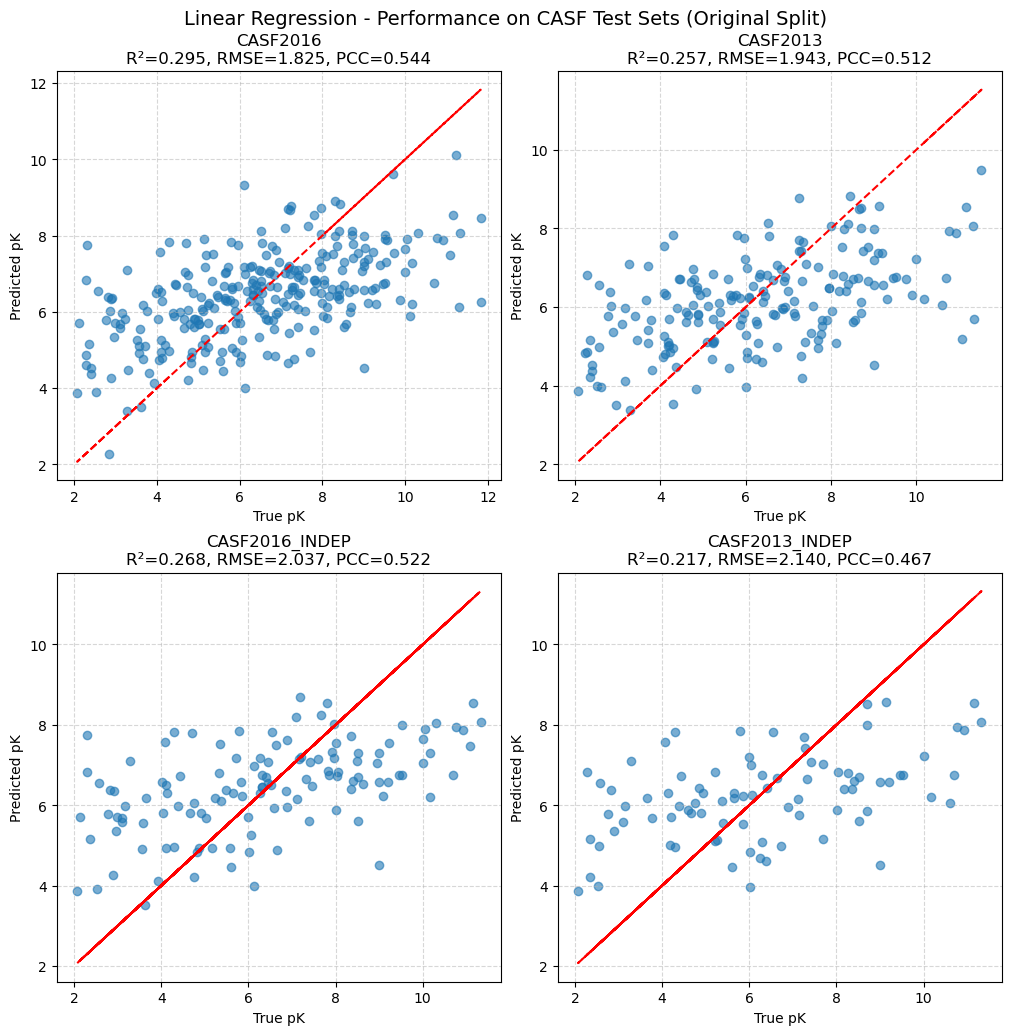

In [24]:
# Model
model = LinearRegression()

# Predict an evaluate for all test sets
evaluate_model(
    model,
    (X_train_orig, y_train_orig),
    test_datasets,
    title="Linear Regression - Performance on CASF Test Sets (Original Split)",
)

- **R-Squared** = A value close to 1  means the model's predictions are very close to the actual data points
- **MSE** = the lower the number to 0, the better
- **Pearson correlation coefficient**: a number between –1 and 1 that measures the strength and direction of the relationship between two variables

#### **HistGradientBoosting Regression**

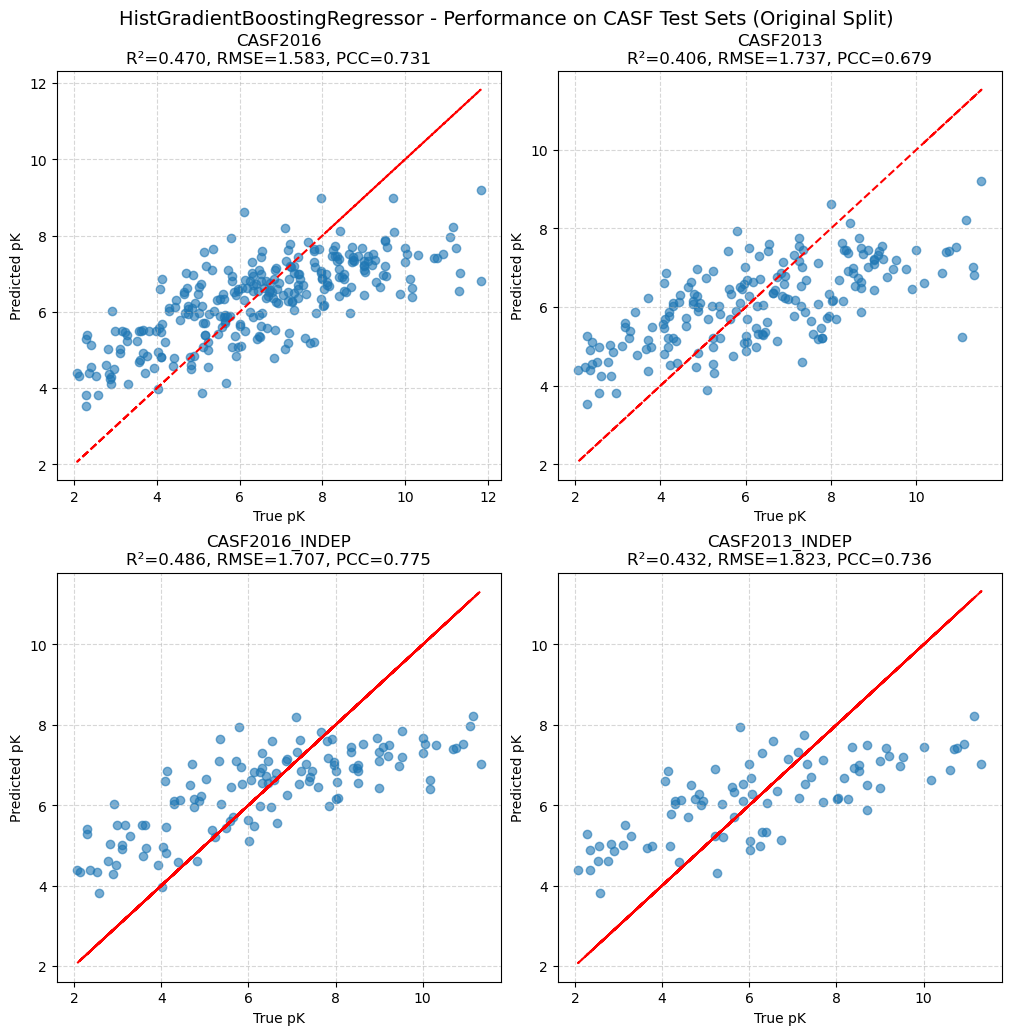

In [25]:
# Model
hgb_model = HistGradientBoostingRegressor(
    learning_rate=0.01,
    max_iter=300,
    max_depth=6,
    random_state=42
)
hgb_model.fit(X_train_orig, y_train_orig)

# Predict an evaluate for all test sets
evaluate_model(
    hgb_model,
    (X_train_orig, y_train_orig),
    test_datasets,
    title="HistGradientBoostingRegressor - Performance on CASF Test Sets (Original Split)",
)

### **RandomizedSearch CV for HistGradientBoosting**

Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'l2_regularization': np.float64(0.0007787658410143283), 'learning_rate': np.float64(0.054610577964560876), 'max_bins': 157, 'max_depth': 8, 'max_iter': 352, 'min_samples_leaf': 58}
Best CV R²: 0.527


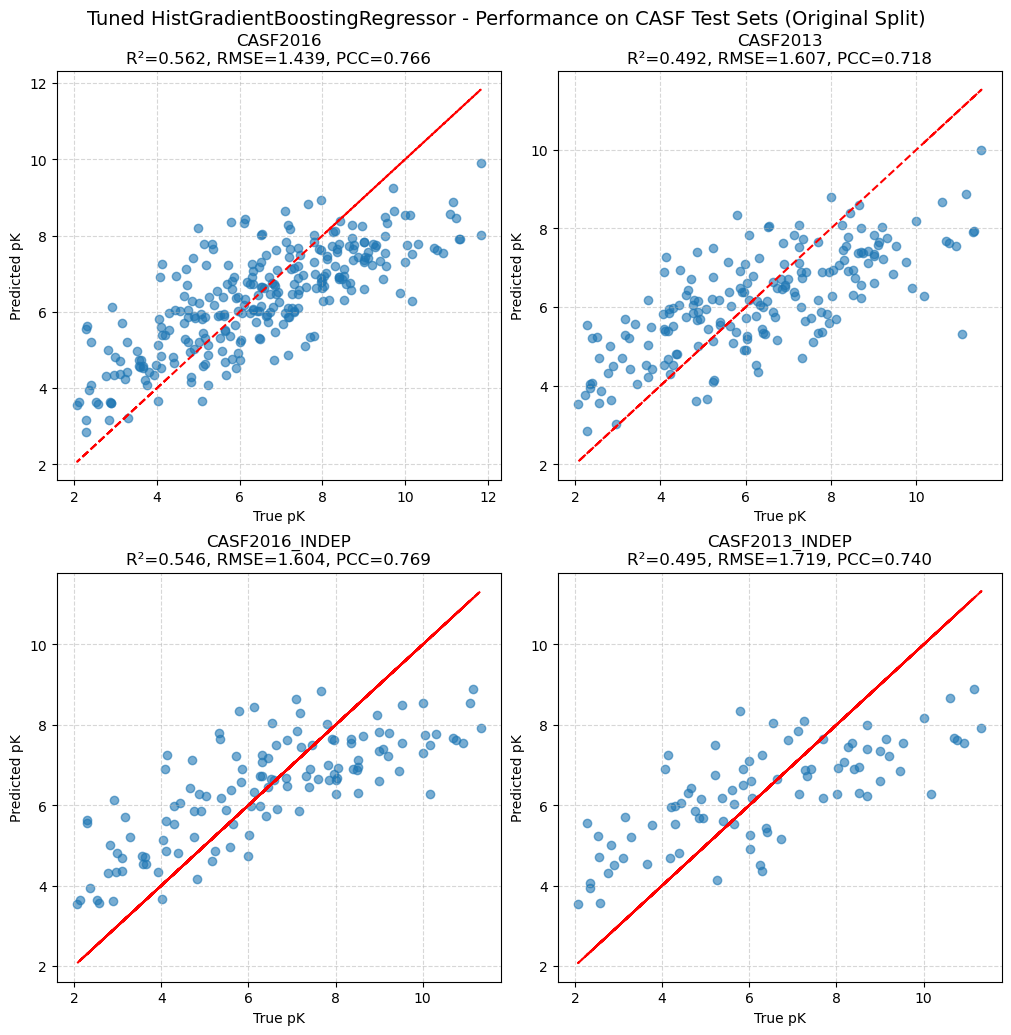

In [31]:
# Parameter grid for RandomizedSearchCV
param_dist = {
    "learning_rate": uniform(0.005, 0.05),   
    "max_iter": randint(100, 600),
    "max_depth": randint(3, 10),
    "min_samples_leaf": randint(10, 80),
    "l2_regularization": uniform(0.0, 1.0),
    "max_bins": randint(100, 255)
}

# Model with RandomizedSearchCV
hgb_model = HistGradientBoostingRegressor(random_state=42)

random_search = RandomizedSearchCV(
    hgb_model,
    param_distributions=param_dist,
    n_iter=20,  
    scoring='r2',
    cv=cv_splits_original, # predefined splits 
    verbose=2, 
    n_jobs=-1,
    random_state=42,
)

random_search.fit(X_train_orig, y_train_orig)

print(random_search.best_params_)
print(f"Best CV R²: {random_search.best_score_:.3f}")

# Best model 
best_hgb = random_search.best_estimator_

# Predict and evaluate for all test sets
evaluate_model(
    best_hgb,
    (X_train_orig, y_train_orig),
    test_datasets,
    title="Tuned HistGradientBoostingRegressor - Performance on CASF Test Sets (Original Split)", 
    fit=False
)

#### **XGBoost**

c:\Users\ravid\.conda\envs\pa2\lib\site-packages\xgboost\core.py:158: UserWarning: [12:34:36] WARNING: D:\bld\xgboost-split_1744329000128\work\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


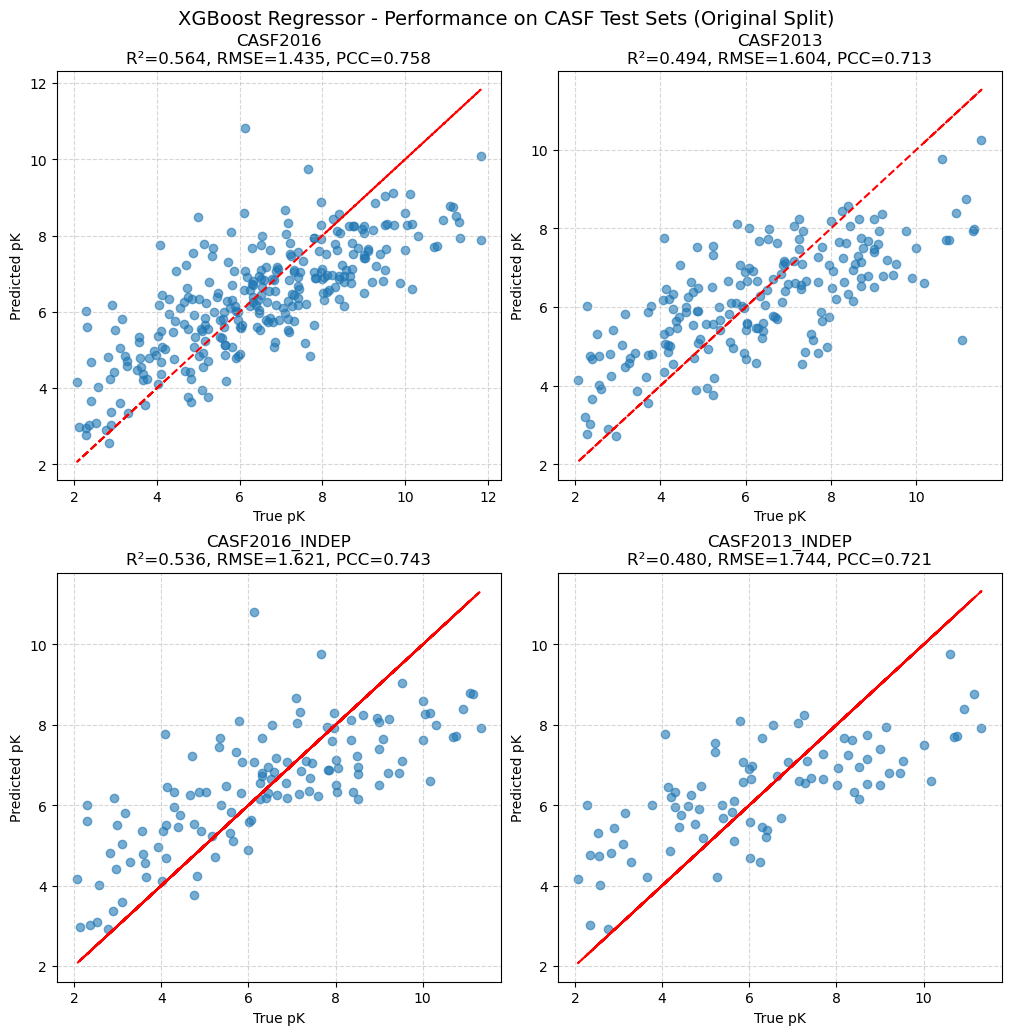

In [28]:
# Model
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
    device="cuda",  
    random_state=42
)

# Predict an evaluate for all test sets
evaluate_model(
    xgb_model,
    (X_train_orig, y_train_orig),
    test_datasets,
    title="XGBoost Regressor - Performance on CASF Test Sets (Original Split)"
)

#### **RandomizedSearch CV for XGBoost**

In [8]:
xgb_model = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    tree_method='hist',
    device='cuda',
    random_state=42
)

params = {
    'n_estimators': randint(300, 1200),          
    'learning_rate': loguniform(1e-3, 0.1),       
    'max_depth': randint(3, 8),                   
    'subsample': uniform(0.7, 0.3),               
    'colsample_bytree': uniform(0.7, 0.3),        
    'reg_alpha': loguniform(1e-3, 10),            
    'reg_lambda': loguniform(0.1, 50)             
}

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=params,
    n_iter=20,                   
    scoring='r2',                
    cv=cv_splits_original,      # predefined splits 
    verbose=2, 
    random_state=42,
    n_jobs=-1,
)

random_search.fit(X_train_orig, y_train_orig)
print(random_search.best_params_)
print(f"Best R²: {random_search.best_score_:.4f}")

# Best model
best_model = random_search.best_estimator_

# Predict an evaluate for all test sets
evaluate_model(
    best_model,
    (X_train_orig, y_train_orig),
    test_datasets,
    title="Tuned XGBoost Regressor - Performance on CASF Test Sets (Original Split)", 
    fit=False
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


: 

---

#### **Regression (clean)**

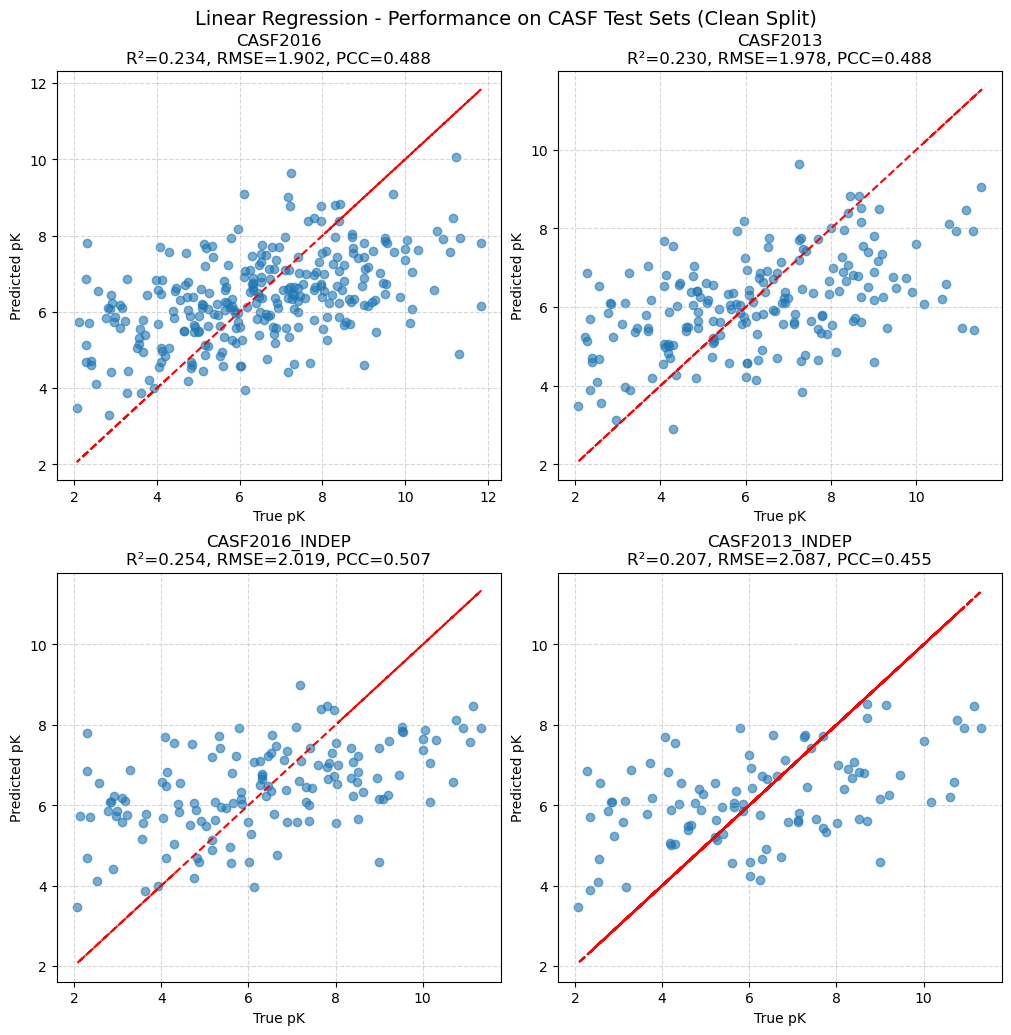

In [7]:
# Model
model_clean = LinearRegression()

# Predict and evaluate for all test sets
evaluate_model(
    model_clean,
    (X_train_clean, y_train_clean),
    test_datasets_clean,
    title="Linear Regression - Performance on CASF Test Sets (Clean Split)",
)

#### **HistGradientBoosting Regression (clean)**

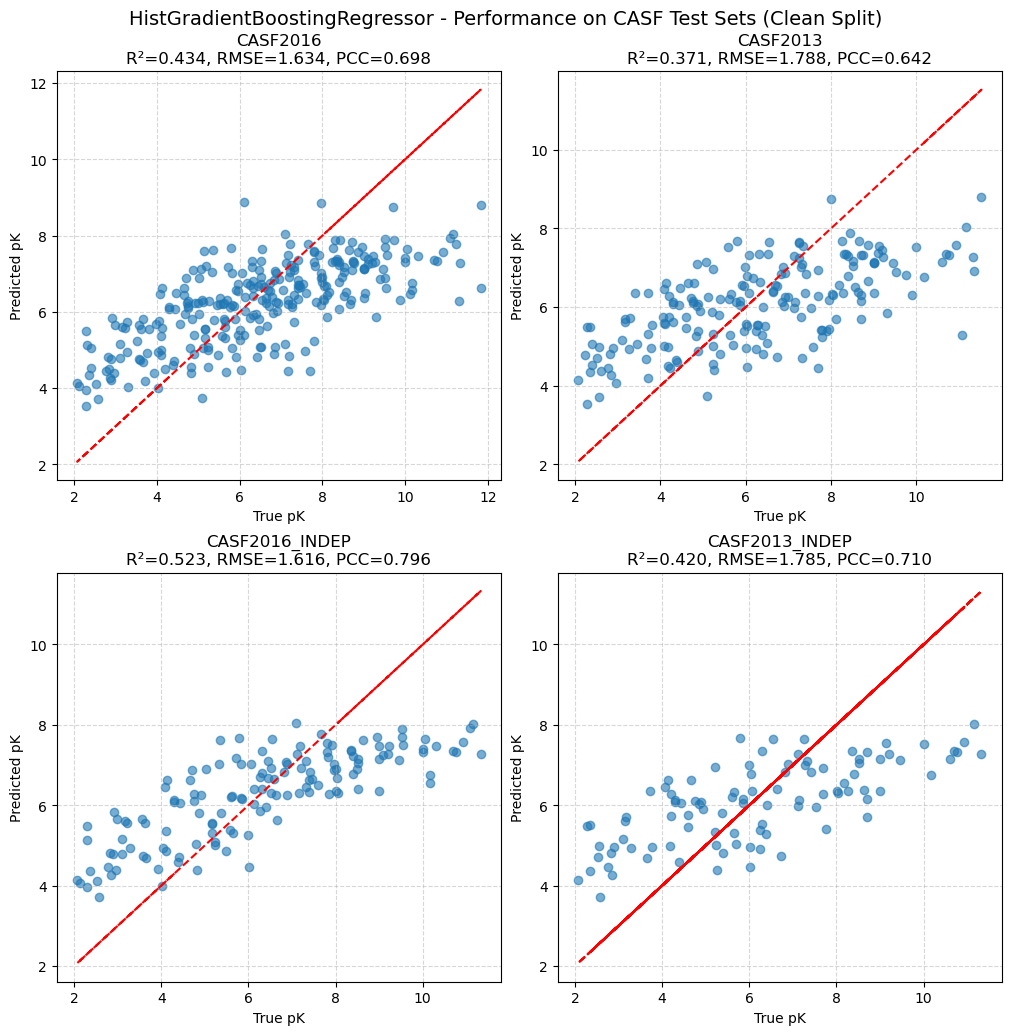

In [8]:
# Model
hgb_model = HistGradientBoostingRegressor(
    learning_rate=0.01,
    max_iter=300,
    max_depth=6,
    random_state=42,
    early_stopping=True
)

# Predict an evaluate for all test sets
evaluate_model(
    hgb_model,
    (X_train_clean, y_train_clean),
    test_datasets_clean,
    title="HistGradientBoostingRegressor - Performance on CASF Test Sets (Clean Split)",
)

### **RandomSearch CV for HistGradientBoosting (clean)**

Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'l2_regularization': np.float64(0.0007787658410143283), 'learning_rate': np.float64(0.054610577964560876), 'max_bins': 157, 'max_depth': 8, 'max_iter': 352, 'min_samples_leaf': 58}
Best CV R²: 0.505


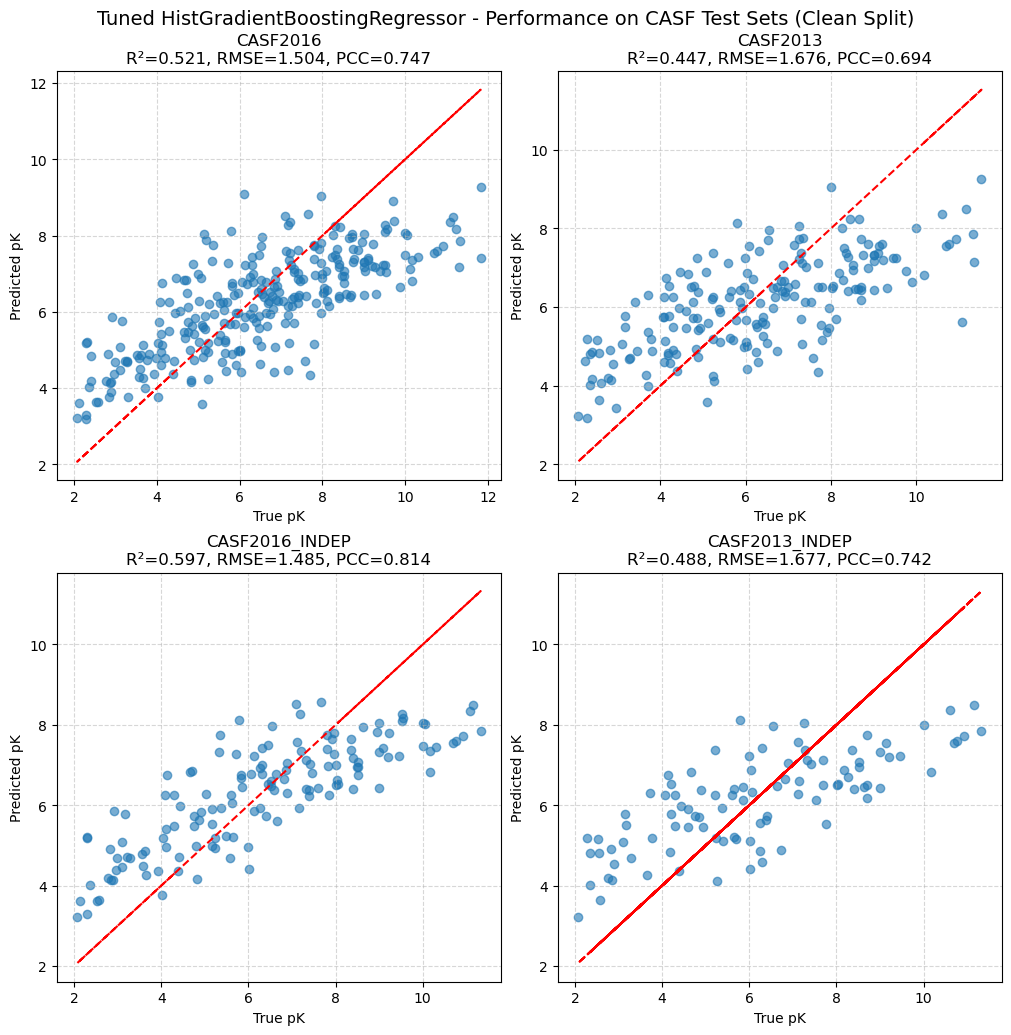

In [9]:
# Parameter grid for RandomizedSearchCV
param_dist = {
    "learning_rate": uniform(0.005, 0.05),
    "max_iter": randint(100, 600),
    "max_depth": randint(3, 10),
    "min_samples_leaf": randint(10, 80),
    "l2_regularization": uniform(0.0, 1.0),
    "max_bins": randint(100, 255)
}

# Model with RandomizedSearchCV
hgb_model = HistGradientBoostingRegressor(random_state=42)

random_search = RandomizedSearchCV(
    hgb_model,
    param_distributions=param_dist,
    n_iter=20,  
    scoring='r2',
    cv=cv_splits_cleansplit, # predefined splits 
    verbose=2, 
    n_jobs=-1,
    random_state=42,
)

random_search.fit(X_train_clean, y_train_clean)

print(random_search.best_params_)
print(f"Best CV R²: {random_search.best_score_:.3f}")

# Best model 
best_hgb = random_search.best_estimator_

# Predict and evaluate for all test sets
evaluate_model(
    best_hgb,
    (X_train_clean, y_train_clean),
    test_datasets_clean,
    title="Tuned HistGradientBoostingRegressor - Performance on CASF Test Sets (Clean Split)", 
    fit=False
)

#### **XGBoost (clean)**

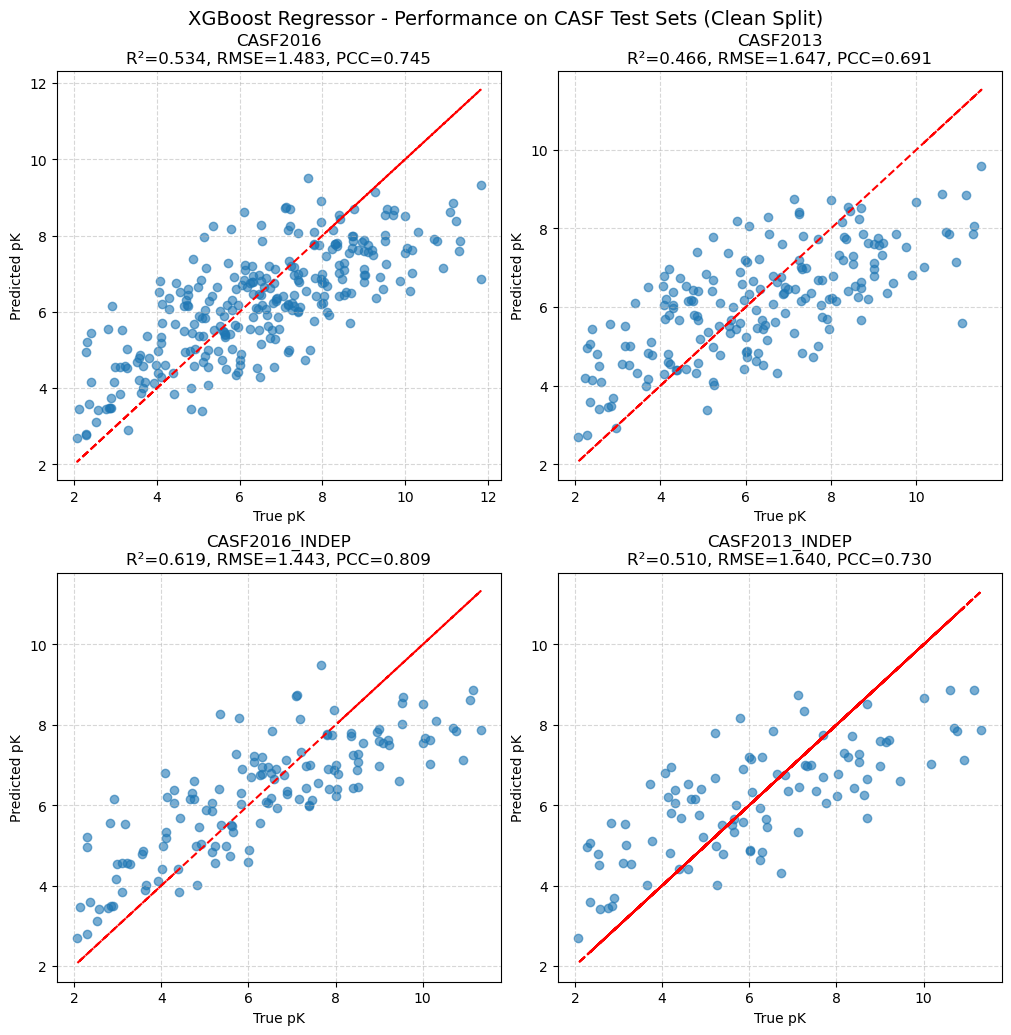

In [10]:
# Model
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
    device="cpu",  
    random_state=42
)

# Predict an evaluate for all test sets
evaluate_model(
    xgb_model,
    (X_train_clean, y_train_clean),
    test_datasets_clean,
    title="XGBoost Regressor - Performance on CASF Test Sets (Clean Split)"
)

#### **RandomSearch CV for XGBoost**

Fitting 5 folds for each of 5 candidates, totalling 25 fits
{'subsample': 0.8, 'reg_lambda': 50, 'reg_alpha': 0.1, 'n_estimators': 600, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best R²: 0.5460


c:\Users\ravid\.conda\envs\pa2\lib\site-packages\xgboost\core.py:158: UserWarning: [17:51:40] WARNING: D:\bld\xgboost-split_1744329000128\work\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


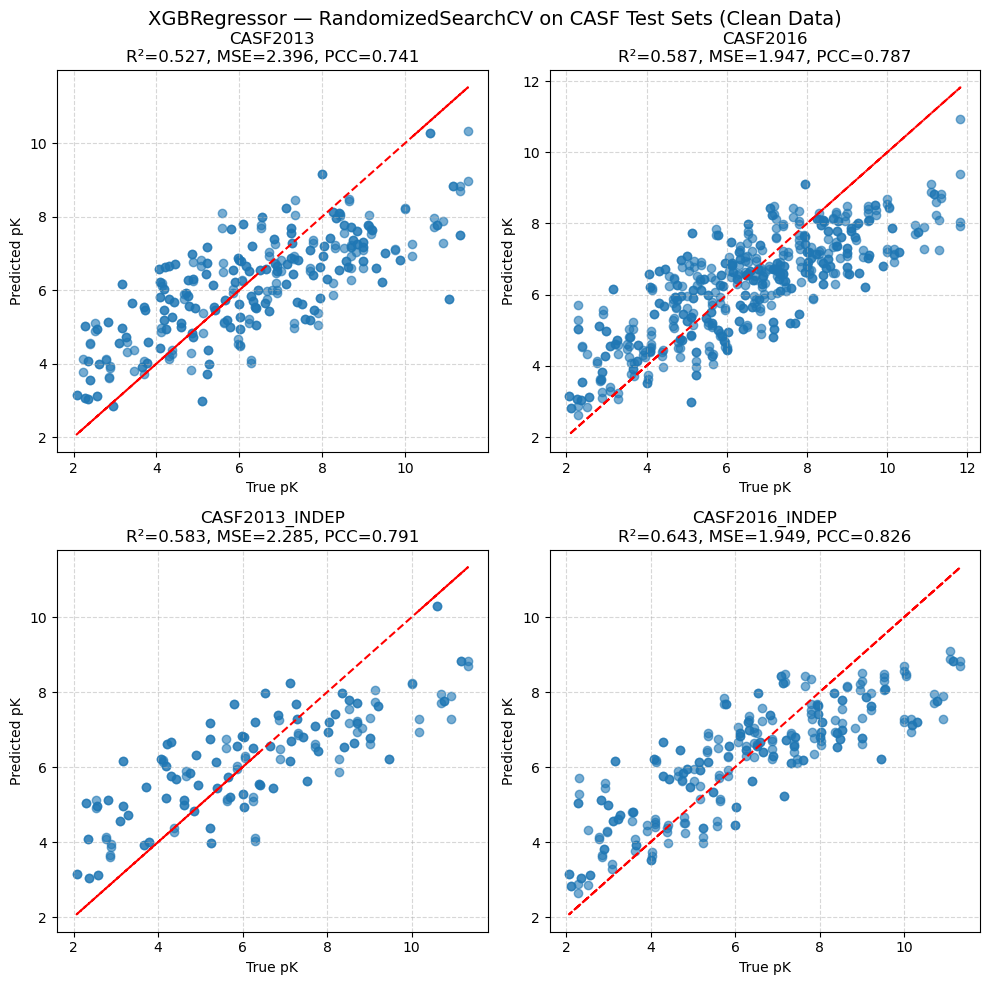

In [ ]:
xgb_model = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    tree_method='hist',
    device='cuda',
    random_state=42
)

params = {
    'n_estimators': randint(300, 1200),          
    'learning_rate': loguniform(1e-3, 0.1),       
    'max_depth': randint(3, 8),                   
    'subsample': uniform(0.7, 0.3),               
    'colsample_bytree': uniform(0.7, 0.3),        
    'reg_alpha': loguniform(1e-3, 10),            
    'reg_lambda': loguniform(0.1, 50)             
}

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=params,
    n_iter=20,                   
    scoring='r2',                
    cv=cv_splits_cleansplit,       # predefined splits 
    verbose=2,
    random_state=42,
    n_jobs=-1,
)

random_search.fit(X_train_clean, y_train_clean)
print(random_search.best_params_)
print(f"Best R²: {random_search.best_score_:.4f}")

# Best model
best_model = random_search.best_estimator_

# Predict an evaluate for all test sets
evaluate_model(
    best_model,
    (X_train_clean, y_train_clean),
    test_datasets_clean,
    title="Tuned XGBoost Regressor - Performance on CASF Test Sets (Clean Split)", 
    fit=False
)